### home work by Vasyl Storchak

In [60]:
import h5py
import numpy as np 
import matplotlib.pyplot as plt
import keras
import cv2
import math
import tensorflow as tf

from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers, models
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras import layers

In [2]:
def load_dataset():
    fn = 'train_signs.h5'
    train_dataset = h5py.File(fn, "r")
    X_train = np.array(train_dataset["train_set_x"][:]) # your train set features
    Y_train = np.array(train_dataset["train_set_y"][:]) # your train set labels

    fn = 'test_signs.h5'
    test_dataset =  h5py.File(fn, "r")
    X_test = np.array(test_dataset["test_set_x"][:]) # your test set features
    Y_test = np.array(test_dataset["test_set_y"][:]) # your test set labels

    classes = np.array(test_dataset["list_classes"][:]) # the list of classes
    
    Y_train = Y_train.reshape((1, Y_train.shape[0]))
    Y_test = Y_test.reshape((1, Y_test.shape[0]))
    
    return X_train, Y_train, X_test, Y_test, classes
    
train_data, train_labels, test_data, test_labels, classes = load_dataset()

print('train_data.shape=', train_data.shape)
print('train_labels.shape=',  train_labels.shape)
print('test_data.shape=', test_data.shape)
print('test_labels.shape=', test_labels.shape)

train_data.shape= (1080, 64, 64, 3)
train_labels.shape= (1, 1080)
test_data.shape= (120, 64, 64, 3)
test_labels.shape= (1, 120)


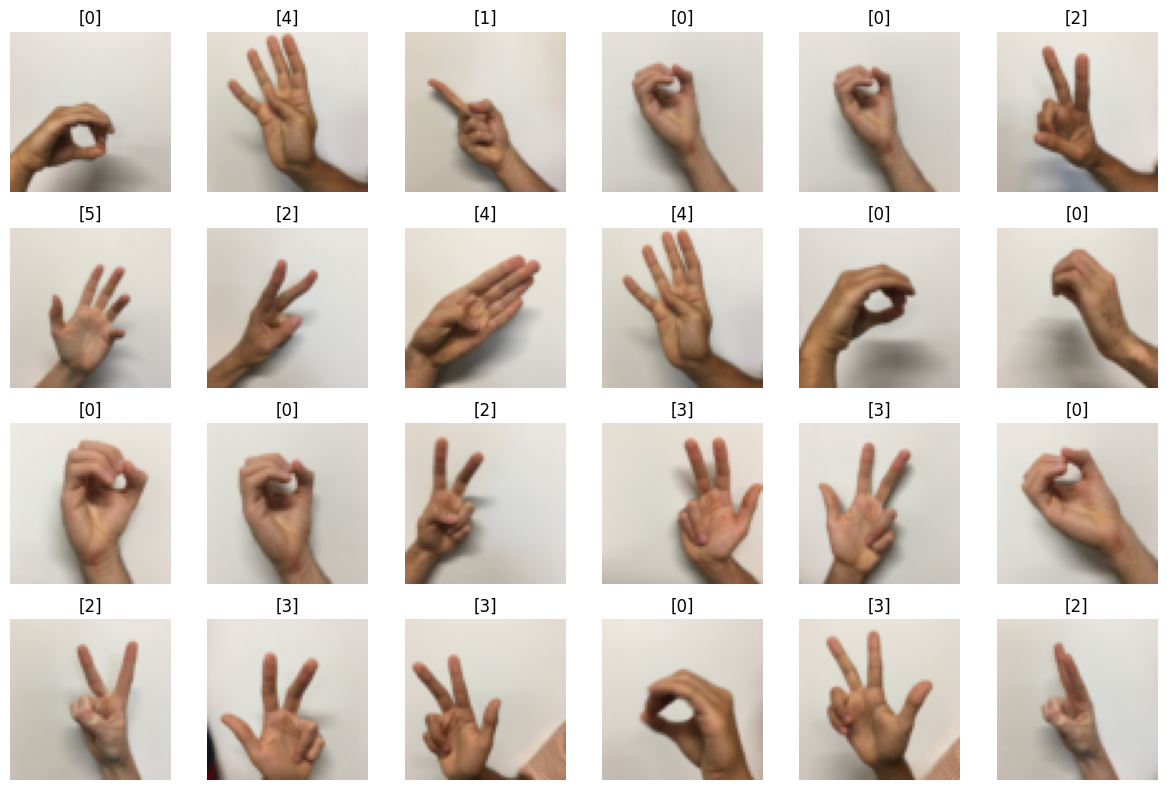

In [6]:
plt.figure(figsize=(12,8))
display_samples_in_grid(train_data, n_rows=4, n_cols=6, y=train_labels.T)
plt.tight_layout(h_pad=1, w_pad=1)

In [ ]:
# prep. data

In [23]:
train_data[0]

array([[[227, 220, 214],
        [227, 221, 215],
        [227, 222, 215],
        ...,
        [232, 230, 224],
        [231, 229, 222],
        [230, 229, 221]],

       [[227, 221, 214],
        [227, 221, 215],
        [228, 221, 215],
        ...,
        [232, 230, 224],
        [231, 229, 222],
        [231, 229, 221]],

       [[227, 221, 214],
        [227, 221, 214],
        [227, 221, 215],
        ...,
        [232, 230, 224],
        [231, 229, 223],
        [230, 229, 221]],

       ...,

       [[119,  81,  51],
        [124,  85,  55],
        [127,  87,  58],
        ...,
        [210, 211, 211],
        [211, 212, 210],
        [210, 211, 210]],

       [[119,  79,  51],
        [124,  84,  55],
        [126,  85,  56],
        ...,
        [210, 211, 210],
        [210, 211, 210],
        [209, 210, 209]],

       [[119,  81,  51],
        [123,  83,  55],
        [122,  82,  54],
        ...,
        [209, 210, 210],
        [209, 210, 209],
        [208, 209, 209]]

In [24]:
train_data = train_data.astype("float32") / 255.0
test_data = test_data.astype("float32") / 255.0

In [25]:
train_data[0]

array([[[0.8901961 , 0.8627451 , 0.8392157 ],
        [0.8901961 , 0.8666667 , 0.84313726],
        [0.8901961 , 0.87058824, 0.84313726],
        ...,
        [0.9098039 , 0.9019608 , 0.8784314 ],
        [0.90588236, 0.8980392 , 0.87058824],
        [0.9019608 , 0.8980392 , 0.8666667 ]],

       [[0.8901961 , 0.8666667 , 0.8392157 ],
        [0.8901961 , 0.8666667 , 0.84313726],
        [0.89411765, 0.8666667 , 0.84313726],
        ...,
        [0.9098039 , 0.9019608 , 0.8784314 ],
        [0.90588236, 0.8980392 , 0.87058824],
        [0.90588236, 0.8980392 , 0.8666667 ]],

       [[0.8901961 , 0.8666667 , 0.8392157 ],
        [0.8901961 , 0.8666667 , 0.8392157 ],
        [0.8901961 , 0.8666667 , 0.84313726],
        ...,
        [0.9098039 , 0.9019608 , 0.8784314 ],
        [0.90588236, 0.8980392 , 0.8745098 ],
        [0.9019608 , 0.8980392 , 0.8666667 ]],

       ...,

       [[0.46666667, 0.31764707, 0.2       ],
        [0.4862745 , 0.33333334, 0.21568628],
        [0.49803922, 0

In [27]:
num_classes = len(np.unique(train_labels))

In [28]:
num_classes

6

In [34]:
train_labels = train_labels.reshape(-1)   # becomes shape (1080,)
test_labels = test_labels.reshape(-1)     # becomes shape (120,)

In [29]:
# model
def build_model(hidden_units=128, activation="relu", dropout_rate=0.5):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation=activation, input_shape=(64,64,3)),
        layers.MaxPooling2D((2,2)),
        
        layers.Conv2D(64, (3,3), activation=activation),
        layers.MaxPooling2D((2,2)),
        
        layers.Conv2D(128, (3,3), activation=activation),
        layers.MaxPooling2D((2,2)),
        
        layers.Flatten(),
        
        layers.Dense(hidden_units, activation=activation),
        layers.Dropout(dropout_rate),
        
        layers.Dense(num_classes, activation="softmax")
    ])
    
    model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

In [30]:
configs = [
    {"hidden_units": 128, "activation": "relu", "dropout_rate": 0.5},
    {"hidden_units": 256, "activation": "tanh", "dropout_rate": 0.3},
    {"hidden_units": 64,  "activation": "sigmoid", "dropout_rate": 0.6},
]

In [58]:
histories = {}

for i, cfg in enumerate(configs):
    print(f"\nTraining model {i+1} with {cfg}")
    model = build_model(**cfg)
    history = model.fit(train_data, 
                        train_labels,
                        validation_data=(test_data, test_labels),
                        epochs=150,
                        batch_size=64,
                        verbose=1)
    histories[f"model_{i+1}"] = history
    model.save(f"sign_classifier_{i}.keras")


Training model 1 with {'hidden_units': 128, 'activation': 'relu', 'dropout_rate': 0.5}
Epoch 1/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 164ms/step - accuracy: 0.1685 - loss: 1.8374 - val_accuracy: 0.1750 - val_loss: 1.7886
Epoch 2/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1804 - loss: 1.7830 - val_accuracy: 0.2250 - val_loss: 1.7568
Epoch 3/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2641 - loss: 1.6903 - val_accuracy: 0.4333 - val_loss: 1.4965
Epoch 4/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4024 - loss: 1.4368 - val_accuracy: 0.5833 - val_loss: 1.2435
Epoch 5/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4757 - loss: 1.3240 - val_accuracy: 0.6833 - val_loss: 1.0250
Epoch 6/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5731 - loss: 1.1409 - val_accuracy: 0.7583 - val_loss: 0.8636
Epoch 7/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6577 - loss: 0.9321 - val_accuracy: 0.7333 - val_loss: 0.7633
Epoch 8/150
17/

In [ ]:
# i see in history the best model 2 by accuracy

In [55]:
histories

{'model_1': <keras.src.callbacks.history.History at 0x7f2d98388770>,
 'model_2': <keras.src.callbacks.history.History at 0x7f2d9867fb00>,
 'model_3': <keras.src.callbacks.history.History at 0x7f2d985b8b00>}

In [ ]:
# 1 = 2

In [63]:
model_1 = load_model("sign_classifier_1.keras")

In [64]:
test_loss, test_acc = model_1.evaluate(test_data, test_labels, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")


Test Accuracy: 0.9417, Test Loss: 0.1764


In [65]:
y_pred_probs = model_1.predict(test_data)
y_pred = np.argmax(y_pred_probs, axis=1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step


In [66]:
print("\nClassification Report:")
print(classification_report(test_labels, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       0.91      1.00      0.95        20
           2       1.00      0.90      0.95        20
           3       0.86      0.95      0.90        20
           4       1.00      0.80      0.89        20
           5       0.91      1.00      0.95        20

    accuracy                           0.94       120
   macro avg       0.95      0.94      0.94       120
weighted avg       0.95      0.94      0.94       120



In [67]:
print("\nConfusion Matrix:")
print(confusion_matrix(test_labels, y_pred))


Confusion Matrix:
[[20  0  0  0  0  0]
 [ 0 20  0  0  0  0]
 [ 0  2 18  0  0  0]
 [ 0  0  0 19  0  1]
 [ 0  0  0  3 16  1]
 [ 0  0  0  0  0 20]]


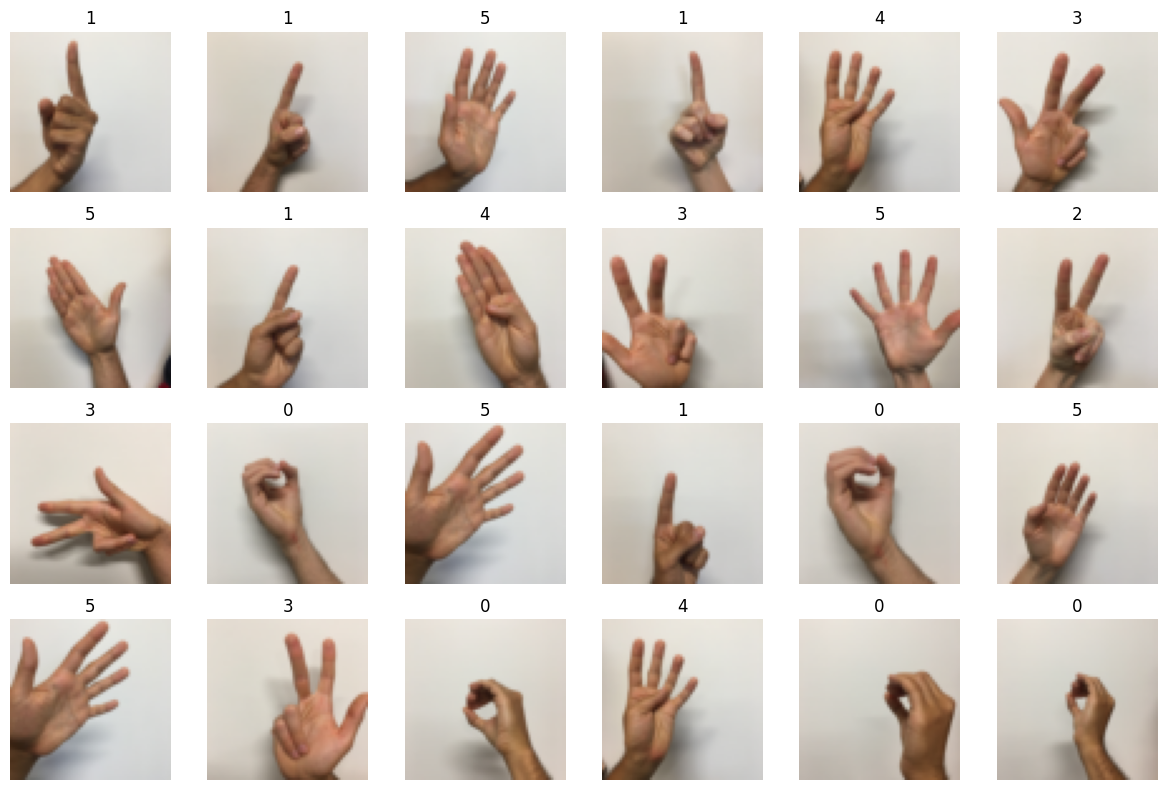

In [68]:
plt.figure(figsize=(12,8))
display_samples_in_grid(test_data, n_rows=4, n_cols=6, y=y_pred.T)
plt.tight_layout(h_pad=1, w_pad=1)

In [ ]:
# tanh the best, but its not clear test